In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression

In [2]:
# 그래프 스타일 설정
sns.set_style("whitegrid")

# 0. 공통 데이터 생성 (데이터 200개)

In [3]:
np.random.seed(42)

income_normal = np.random.normal(5000, 1500, 150)
balance_normal = np.random.normal(800, 300, 150)
default_normal = np.zeros(150) # 0: 정상 (No Default)

income_default = np.random.normal(4500, 1500, 50)
balance_default = np.random.normal(1800, 400, 50)
default_default = np.ones(50) # 1: 연체 (Default)

income = np.concatenate([income_normal, income_default])
balance = np.concatenate([balance_normal, balance_default])
default = np.concatenate([default_normal, default_default])
df = pd.DataFrame({'Income': income, 'Balance': balance, 'Default': default})

# [시각화 1] 소득 vs 카드 사용량 산점도 (정사각형)

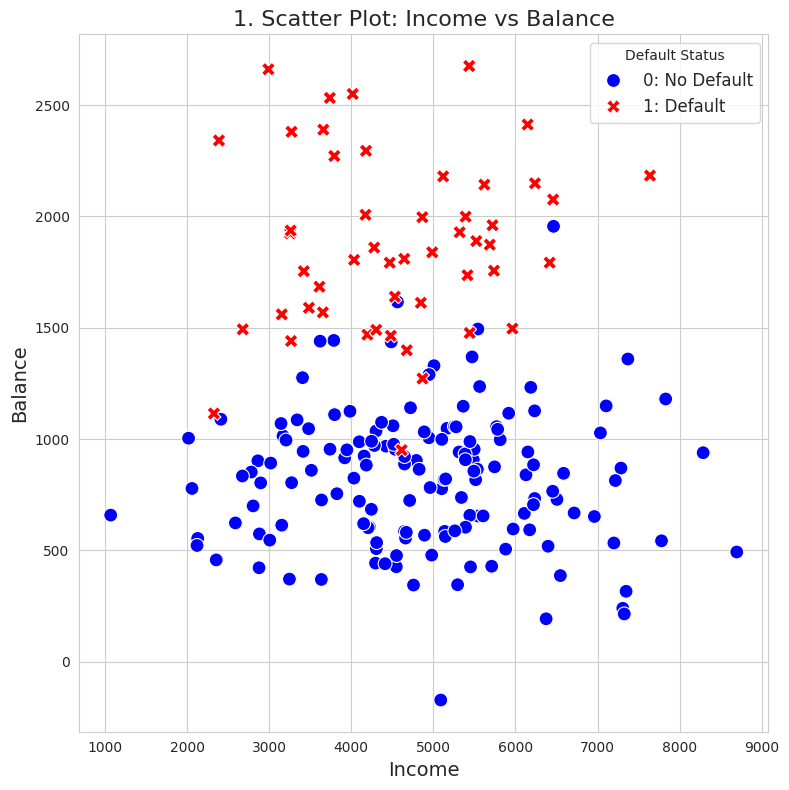

In [6]:
df['Status_Label'] = df['Default'].map({0: '0: No Default', 1: '1: Default'})

plt.figure(figsize=(8, 8))

# hue와 style을 새로 만든 'Status_Label'로 지정해 줍니다.
sns.scatterplot(x='Income', y='Balance', hue='Status_Label', style='Status_Label', data=df, 
                palette={'0: No Default': 'blue', '1: Default': 'red'}, 
                markers={'0: No Default': 'o', '1: Default': 'X'}, s=100)

plt.title('1. Scatter Plot: Income vs Balance', fontsize=16)
plt.xlabel('Income', fontsize=14)
plt.ylabel('Balance', fontsize=14)

# 데이터에 라벨이 이미 있으므로 title과 폰트 크기만 지정해주면 알아서 예쁘게 그려집니다.
plt.legend(title='Default Status', fontsize=12)

plt.tight_layout()
plt.show()

# [시각화 1-2] 상자 수염 그림 (Boxplot) + 실제 데이터 분포 (Stripplot)

/tmp/ipykernel_92/2629356554.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status_Label', y='Balance', data=df,


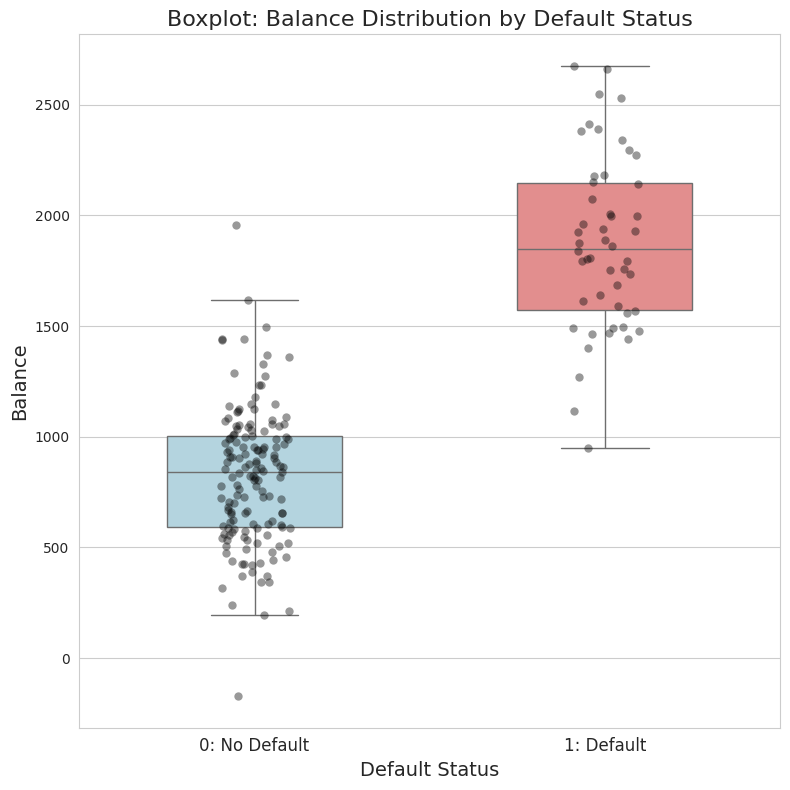

In [7]:
plt.figure(figsize=(8, 8))

# 1. 상자 수염 그림 그리기 (정상: 옅은 파란색, 연체: 옅은 빨간색)
sns.boxplot(x='Status_Label', y='Balance', data=df, 
            palette={'0: No Default': 'lightblue', '1: Default': 'lightcoral'}, 
            width=0.5, showfliers=False) # showfliers=False: 기본 이상치 점은 숨김 (stripplot과 겹치지 않게)

# 2. 이해를 돕기 위해 그 위에 실제 데이터 점들을 흩뿌려서 겹쳐 그리기
sns.stripplot(x='Status_Label', y='Balance', data=df, 
              color='black', alpha=0.4, jitter=True, size=6)

plt.title('Boxplot: Balance Distribution by Default Status', fontsize=16)
plt.xlabel('Default Status', fontsize=14)
plt.ylabel('Balance', fontsize=14)
plt.xticks(fontsize=12)

plt.tight_layout()
plt.show()

# [시각화 2] 선형회귀 vs 로지스틱 회귀 비교 (정사각형)

/opt/conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


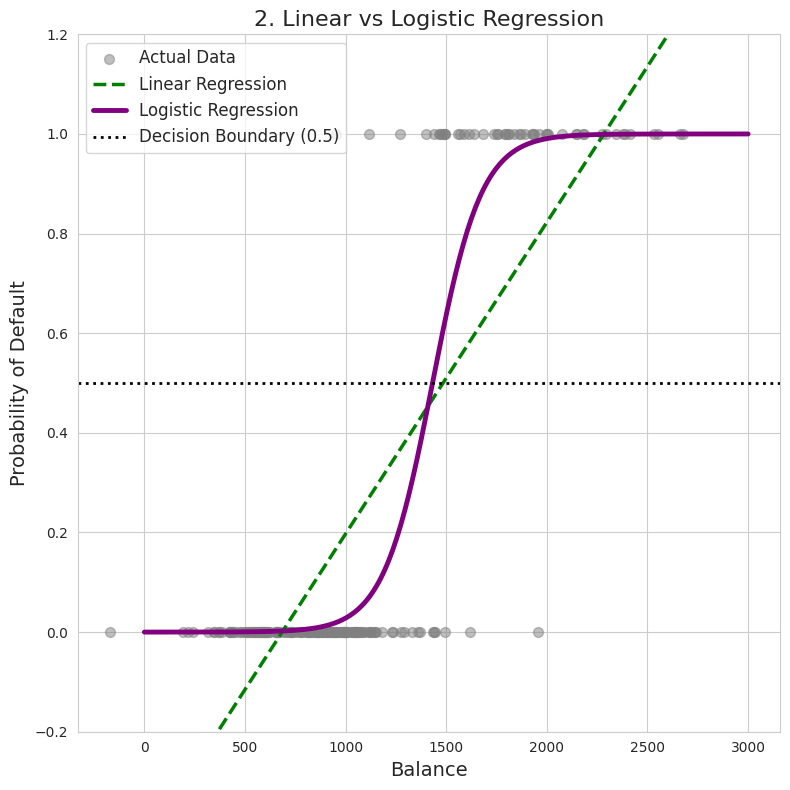

In [8]:
plt.figure(figsize=(8, 8))

X_balance = df[['Balance']]
y_default = df['Default']

# 모델 학습
lin_model = LinearRegression()
lin_model.fit(X_balance, y_default)

log_model = LogisticRegression()
log_model.fit(X_balance, y_default)

X_test = np.linspace(0, 3000, 300).reshape(-1, 1)
y_lin_pred = lin_model.predict(X_test)
y_log_pred_prob = log_model.predict_proba(X_test)[:, 1]

# 그래프 그리기
plt.scatter(df['Balance'], df['Default'], color='gray', alpha=0.5, label='Actual Data', s=50)
plt.plot(X_test, y_lin_pred, color='green', linestyle='--', linewidth=2.5, label='Linear Regression')
plt.plot(X_test, y_log_pred_prob, color='purple', linewidth=3.5, label='Logistic Regression')
plt.axhline(0.5, color='black', linestyle=':', linewidth=2, label='Decision Boundary (0.5)')

plt.title('2. Linear vs Logistic Regression', fontsize=16)
plt.xlabel('Balance', fontsize=14)
plt.ylabel('Probability of Default', fontsize=14)
plt.ylim(-0.2, 1.2) 
plt.legend(loc='upper left', fontsize=12)

# 두 번째 그래프 출력 완료
plt.tight_layout()
plt.show()

# 로지스틱 회귀 모델 학습 및 결과 해석

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. 가상의 신용카드 연체 데이터 생성 (기존과 동일)
np.random.seed(42)
income_normal = np.random.normal(5000, 1500, 150)
balance_normal = np.random.normal(800, 300, 150)
default_normal = np.zeros(150)

income_default = np.random.normal(4500, 1500, 50)
balance_default = np.random.normal(1800, 400, 50)
default_default = np.ones(50)

income = np.concatenate([income_normal, income_default])
balance = np.concatenate([balance_normal, balance_default])
default = np.concatenate([default_normal, default_default])
df = pd.DataFrame({'Income': income, 'Balance': balance, 'Default': default})

# 2. 데이터 분리 (학습용 80%, 테스트용 20%)
X = df[['Income', 'Balance']] # 이번엔 소득과 카드 사용량 둘 다 넣어봅시다!
y = df['Default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 로지스틱 회귀 모델 학습
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# 4. 결과(회귀 계수) 출력 및 해석
print("=== 로지스틱 회귀 모델 학습 결과 ===")
print(f"절편 (Intercept, 베이스라인): {log_model.intercept_[0]:.4f}")
print(f"소득(Income) 계수: {log_model.coef_[0][0]:.4f}")
print(f"카드 사용량(Balance) 계수: {log_model.coef_[0][1]:.4f}\n")

print("=== 계수의 직관적 해석 (Odds Ratio, 오즈비) ===")
# 로지스틱 회귀의 계수는 '로그'가 씌워져 있으므로, 이를 원래 비율로 되돌리려면 지수(exp) 함수를 취해야 합니다.
odds_income = np.exp(log_model.coef_[0][0])
odds_balance = np.exp(log_model.coef_[0][1])

print(f"소득이 1 늘어날 때, 연체될 확률(오즈)은 {odds_income:.4f}배가 됩니다.")
print(f"카드 사용량이 1 늘어날 때, 연체될 확률(오즈)은 {odds_balance:.4f}배가 됩니다.")

=== 로지스틱 회귀 모델 학습 결과 ===
절편 (Intercept, 베이스라인): -9.3569
소득(Income) 계수: -0.0010
카드 사용량(Balance) 계수: 0.0099

=== 계수의 직관적 해석 (Odds Ratio, 오즈비) ===
소득이 1 늘어날 때, 연체될 확률(오즈)은 0.9990배가 됩니다.
카드 사용량이 1 늘어날 때, 연체될 확률(오즈)은 1.0099배가 됩니다.
